<a href="https://colab.research.google.com/github/chantellgebauer/AnalisisNotas/blob/main/Pinguinos_Palmer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Import packages
import pandas as pd
import seaborn as sns

# Load dataset
penguins = sns.load_dataset("penguins")

# Examine first 5 rows of dataset
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


A efectos de este curso, centraremos nuestro análisis en los pingüinos Adelia y papúa, y descartaremos cualquier valor perdido del conjunto de datos. En un entorno laboral, lo habitual sería examinar los datos más a fondo antes de decidir cómo tratar los datos perdidos (es decir, completarlos, descartarlos, etc.).

In [6]:
# Conservar los pingüinos Adelia y papúa; descartar los valores que faltan
penguins_sub = penguins[penguins["species"] != "Chinstrap"]
penguins_final = penguins_sub.dropna()
penguins_final.reset_index(inplace=True, drop=True)

Puedes consultar la documentación de dropna() y reset_index(). En resumen, la función dropna() elimina por defecto cualquier fila que contenga valores perdidos en cualquiera de las columnas. La función reset_index() restablece los valores del índice de las filas del DataFrame. Por lo general, se utiliza reset_index() una vez que se ha terminado de manipular el conjunto de datos. Al establecer inplace=True, no se creará un nuevo objeto DataFrame. Al establecer drop=True, no se insertará una nueva columna de índice en el objeto DataFrame.

**Análisis exploratorio de datos**
Antes de construir cualquier modelo, es importante familiarizarse mejor con los datos. Para ello, puedes realizar un análisis exploratorio de datos (EDA, por sus siglas en inglés). Revisa los materiales del programa anteriores según sea necesario si deseas refrescar tus conocimientos sobre los conceptos del EDA.

Dado que esta parte del curso se centra en la regresión lineal simple, es conveniente comprobar si existen relaciones lineales entre las variables del marco de datos. Para ello, puede crear diagramas de dispersión utilizando cualquier paquete de visualización de datos, como matplotlib.plt, seaborn o plotly.

Para visualizar más de una relación al mismo tiempo, utilizamos la función pairplot() del paquete seaborn para crear una matriz de diagramas de dispersión.

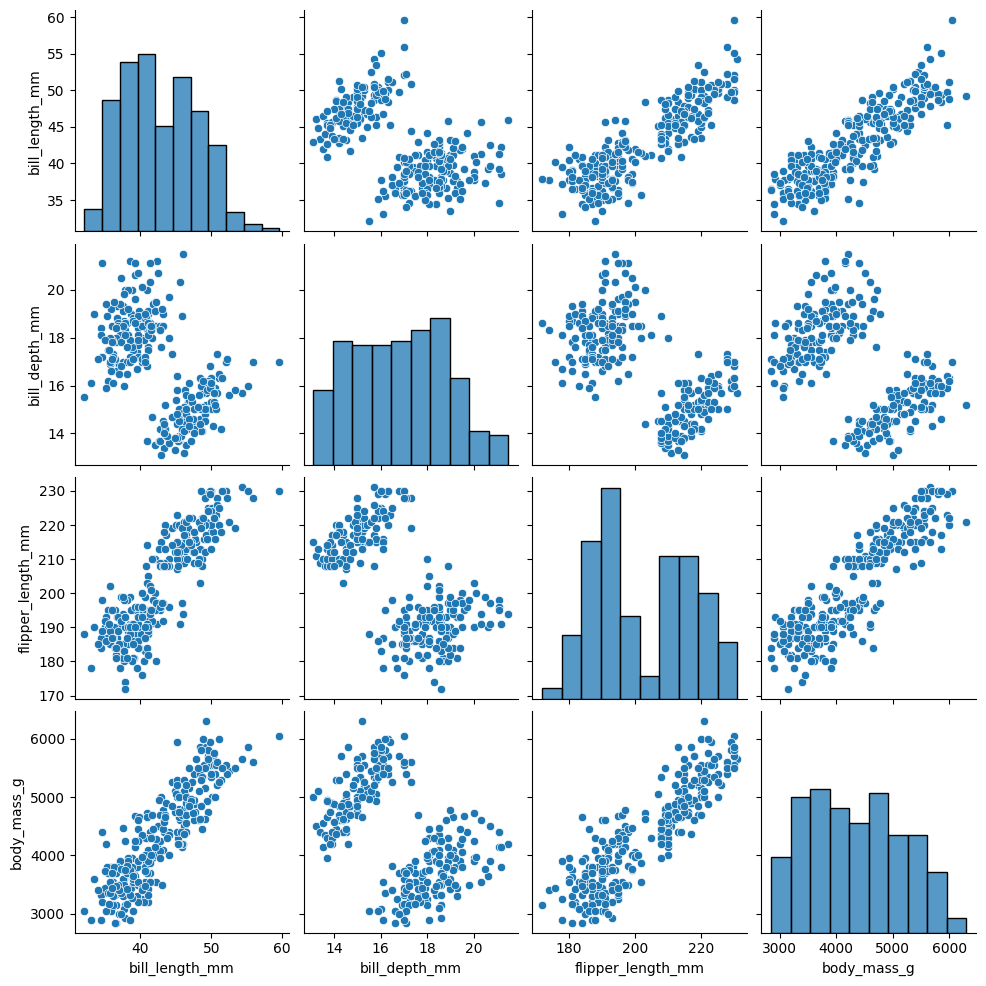

In [7]:
# Crear diagramas de dispersión por pares del conjunto de datos
# Create pairwise scatterplots of data set
sns.pairplot(penguins_final)


En la matriz de diagramas de dispersión se pueden observar algunas relaciones lineales:

longitud del pico (mm) y longitud de la aleta (mm)
longitud del pico (mm) y masa corporal (g)
longitud de la aleta (mm) y masa corporal (g)

From the scatterplot matrix, you can observe a few linear relationships:

bill length (mm) and flipper length (mm)
bill length (mm) and body mass (g)
flipper length (mm) and body mass (g)

**Elaboración del modelo**
A partir de los diagramas de dispersión anteriores, probablemente podrías realizar una regresión lineal simple sobre cualquiera de las tres relaciones identificadas. En esta parte del curso, te centrarás en la relación entre la longitud del pico (mm) y la masa corporal (g).

Para ello, primero deberás extraer del marco de datos un subconjunto de las variables que te interesan. Puedes hacerlo utilizando corchetes dobles [[]] y enumerando los nombres de las columnas que te interesan.

Model construction
Based on the above scatterplots, you could probably run a simple linear regression on any of the three relationships identified. For this part of the course, you will focus on the relationship between bill length (mm) and body mass (g).

To do this, you will first subset the variables of interest from the dataframe. You can do this by using double square brackets [[]], and listing the names of the columns of interest.

In [9]:
#Subconjunto de Data
# Subset Data
ols_data = penguins_final[["bill_length_mm", "body_mass_g"]]

A continuación, puedes crear la fórmula de regresión lineal y guardarla como una cadena de caracteres. Recuerda que la variable y (o variable dependiente) va antes del símbolo ~, y la variable x (o variable independiente) va después del símbolo ~.

Nota: Los nombres de las variables x e y deben coincidir exactamente con los nombres de las columnas del marco de datos.

Next, you can construct the linear regression formula, and save it as a string. Remember that the y or dependent variable comes before the ~, and the x or independent variables comes after the ~.

Note: The names of the x and y variables have to exactly match the column names in the dataframe.

In [10]:
# Write out formula
# Escribe la fórmula
ols_formula = "body_mass_g ~ bill_length_mm"

Por último, puedes crear el modelo de regresión lineal simple en statsmodels utilizando la función ols(). Puedes importar la función ols() directamente con la siguiente línea de código.

In [11]:
# Import ols function
from statsmodels.formula.api import ols

A continuación, puedes introducir `ols_formula` y `ols_data` como argumentos en la función `ols()`. Una vez guardados los resultados en una variable, puedes llamar a la función `fit()` para ajustar el modelo a los datos.

In [12]:
# Build OLS, fit model to data
OLS = ols(formula = ols_formula, data = ols_data)
model = OLS.fit()

Por último, puedes llamar a la función summary() sobre el objeto del modelo para obtener los coeficientes y más estadísticas sobre el modelo. El resultado de model.summary() se puede utilizar para evaluar el modelo e interpretar los resultados. Más adelante en esta sección, veremos cómo interpretar los resultados del modelo.

In [13]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     874.3
Date:                Tue, 05 May 2026   Prob (F-statistic):           1.33e-85
Time:                        14:24:45   Log-Likelihood:                -1965.8
No. Observations:                 265   AIC:                             3936.
Df Residuals:                     263   BIC:                             3943.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -1707.2919    205.640     -8.302      0.000   -2112.202   -1302.382
bill_length_mm   141.1904      4.775     29.569      0.000     131.788     150.592
==============================================================================
Omnibus:                        2.060   Durbin-Watson:                   2.067
Prob(Omnibus):                  0.357   Jarque-Bera (JB):                2.103
Skew:                           0.210   Prob(JB):                        0.349
Kurtosis:                       2.882   Cond. No.                         357.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

You can use the regplot() function from seaborn to visualize the regression line.

<Axes: xlabel='bill_length_mm', ylabel='body_mass_g'>

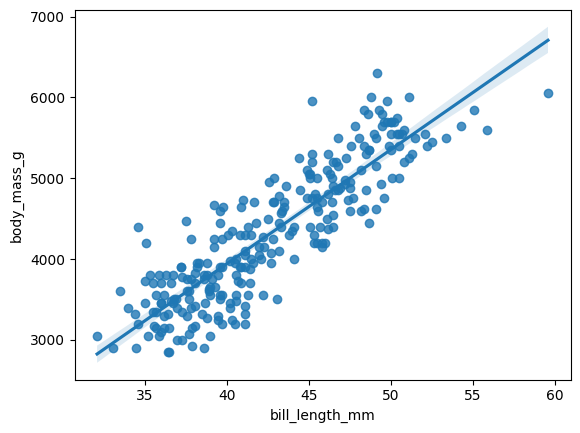

In [14]:
sns.regplot(x = "bill_length_mm", y = "body_mass_g", data = ols_data)

Finaliza la comprobación de los supuestos del modelo
Como has aprendido en los vídeos anteriores, hay cuatro supuestos principales del modelo para la regresión lineal simple, sin ningún orden en particular:

Linealidad
Normalidad
Observaciones independientes
Homoscedasticidad
Ya has comprobado el supuesto de linealidad al crear la matriz de diagramas de dispersión. El supuesto de observaciones independientes tiene más que ver con la recopilación de datos. No hay motivos para creer que la masa corporal o la longitud del pico de un pingüino estén relacionadas con las medidas anatómicas de cualquier otro pingüino. Por lo tanto, podemos descartar los supuestos 1 y 3.

Los supuestos de normalidad y homocedasticidad se centran en la distribución de los errores. Por lo tanto, solo puedes verificar estos supuestos después de haber construido el modelo. Para verificar estos supuestos, comprobarás los residuos, como una aproximación de los errores.

Para comprobar más fácilmente los supuestos del modelo y crear visualizaciones relevantes, primero puede crear un subconjunto de la variable X aislando únicamente la columna bill_length_mm. Además, puede guardar los valores predichos del modelo utilizando la función model.predict(X).





In [15]:
# Subset X variable
X = ols_data["bill_length_mm"]

# Get predictions from model
fitted_values = model.predict(X)

A continuación, puedes guardar los residuos del modelo como una variable utilizando el atributo `model.resid`.

In [16]:
# Calculate residuals
residuals = model.resid

Comprobar la hipótesis de normalidad
Para comprobar la hipótesis de normalidad, puedes crear un histograma de los residuos utilizando la función histplot() del paquete seaborn.

En el histograma que se muestra a continuación, se puede observar que los residuos siguen una distribución casi normal. En este caso, es probable que se acerque lo suficiente como para que se cumpla la hipótesis.

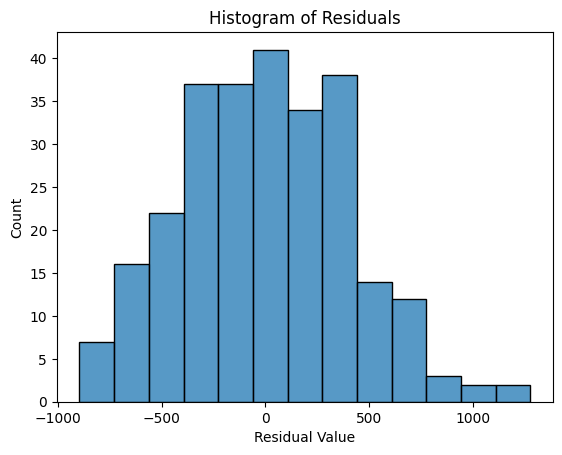

In [17]:
import matplotlib.pyplot as plt
fig = sns.histplot(residuals)
fig.set_xlabel("Residual Value")
fig.set_title("Histogram of Residuals")
plt.show()

Comprueba la hipótesis de homocedasticidad
Por último, debemos comprobar la hipótesis de homocedasticidad. Para ello, puedes crear un diagrama de dispersión con los valores estimados y los residuos. Si el gráfico se asemeja a una nube aleatoria (es decir, los residuos están dispersos de forma aleatoria), es probable que se cumpla la hipótesis.

Puede crear un gráfico de dispersión utilizando la función scatterplot() del paquete seaborn. El primer argumento es la variable que va en el eje x. El segundo argumento es la variable que va en el eje y.

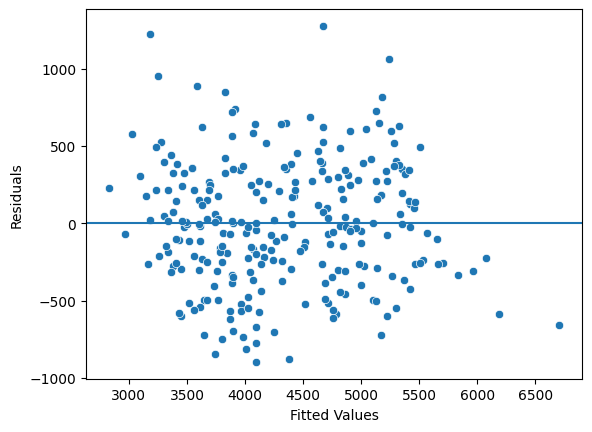

In [18]:
# Import matplotlib
import matplotlib.pyplot as plt
fig = sns.scatterplot(x=fitted_values, y=residuals)

# Add reference line at residuals = 0
fig.axhline(0)

# Set x-axis and y-axis labels
fig.set_xlabel("Fitted Values")
fig.set_ylabel("Residuals")

# Show the plot
plt.show()